### REGRESIÓN LOGÍSTICA

### REGULARIZACIÓN, EJEMPLO POLINOMIAL

## 1. Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## 2. Creación de la función polinomial

### 2.1 Crear variables

In [2]:
# x1 comience en -1.3 y finalice em 3.5 con una distancia de 0.125.
x1 = np.arange(-1.3,3.5, 0.125)

In [3]:
x2 = x1 * x1
x3 = x1 * x1 * x1

### 2.2 Crear dataframe

In [4]:
w = np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)           # vstack convierte las variables en vectores columna y luego se concatenan horizontalmente para formar la matriz de diseño.

### 2.3 Crear la tabla 

In [5]:
X = pd.DataFrame(w, columns=['x1', 'x2', 'x3'])

### 2.4 Definir la influencia de los pesos

In [6]:
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3

### 2.5 Introducir el ruido a la función

In [7]:
noise = 200 * (random.random() - 0.5)           #r andom.ramdom() genera # aleatorio entre 0 y 1
                                                # restando 0.5 se obtiene un # entre -0.5 y 0.5, multiplicando por 200 se obtiene # entre -100 y 100.

In [8]:
X.head()

,x1,x2,x3
0,-1.300,1.690000,-2.197000
1,-1.175,1.380625,-1.622234
2,-1.050,1.102500,-1.157625
3,-0.925,0.855625,-0.791453
4,-0.800,0.640000,-0.512000


### 2.6 Gráfico de la función polinomial

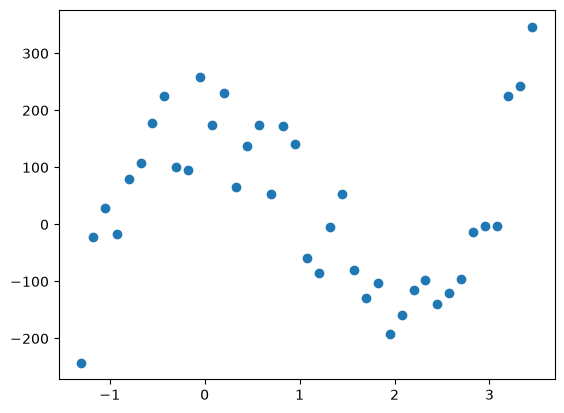

In [9]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)

plt.scatter(x1,yreal)
plt.show()

## 3. Definición de Modelos

In [12]:
# Definamos 4 modelos: RLM, RLM con L1, RLM con L2 y RLM con L3:

modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))  
modelos.append(('RIDGE', Ridge(alpha=30)))  
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

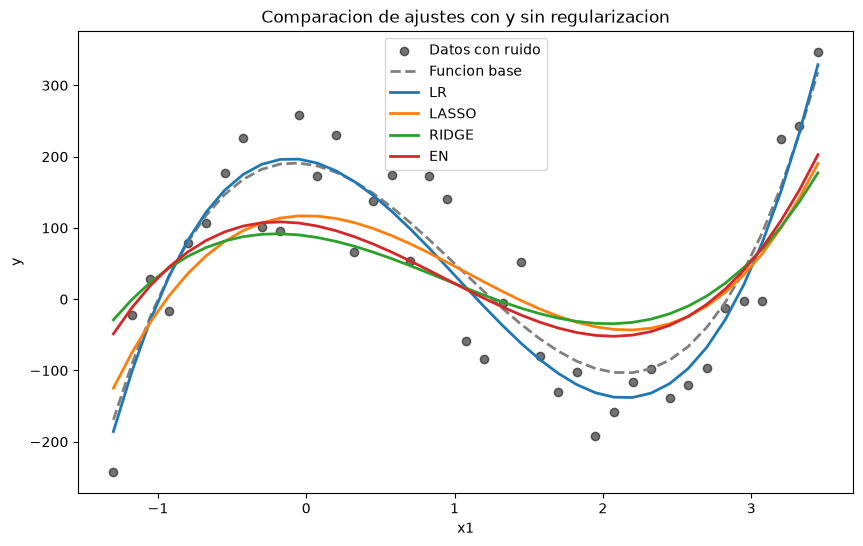

,modelo,intercepto,coef_x1,coef_x2,coef_x3,r2,mae
0,LR,194.916384,-40.149798,-179.703500,58.727544,0.842725,46.885452
1,LASSO,117.130694,-0.000000,-102.252536,31.427217,0.628918,77.028296
2,RIDGE,88.972948,-27.515733,-61.847347,22.388043,0.521572,83.106607
3,EN,105.481680,-32.106553,-79.346455,28.064349,0.614904,74.542077


In [11]:
y = np.array(yreal)

for _, modelo in modelos:
    modelo.fit(X, y)

yhat0 = modelos[0][1].predict(X)
yhat1 = modelos[1][1].predict(X)
yhat2 = modelos[2][1].predict(X)
yhat12 = modelos[3][1].predict(X)

ybase = w3*np.power(x1, 3) + w2*np.power(x1, 2) + w1*x1 + w0

plt.figure(figsize=(10, 6))
plt.scatter(x1, y, color='black', alpha=0.55, label='Datos con ruido')
plt.plot(x1, ybase, linestyle='--', linewidth=2, color='gray', label='Funcion base')
plt.plot(x1, yhat0, linewidth=2, label='LR')
plt.plot(x1, yhat1, linewidth=2, label='LASSO')
plt.plot(x1, yhat2, linewidth=2, label='RIDGE')
plt.plot(x1, yhat12, linewidth=2, label='EN')
plt.xlabel('x1')
plt.ylabel('y')
plt.title('Comparacion de ajustes con y sin regularizacion')
plt.legend()
plt.show()

resumen = []
predicciones = [
    ('LR', yhat0, modelos[0][1]),
    ('LASSO', yhat1, modelos[1][1]),
    ('RIDGE', yhat2, modelos[2][1]),
    ('EN', yhat12, modelos[3][1])
]

for nombre, yhat, modelo in predicciones:
    resumen.append({
        'modelo': nombre,
        'intercepto': float(np.ravel(modelo.intercept_)[0]),
        'coef_x1': float(modelo.coef_[0]),
        'coef_x2': float(modelo.coef_[1]),
        'coef_x3': float(modelo.coef_[2]),
        'r2': float(modelo.score(X, y)),
        'mae': float(np.mean(np.abs(y - yhat)))
    })

pd.DataFrame(resumen)


## 4. Conclusiones

LR: Valores de MLR relativamente cercanos a los valores originales, no van a ser = debido al ruido integrado. 

LSSO: Eliminó el coeficiente lineal debido a que el mismo aportaba poco en la información. 

RIDGE: Disminuyó la magnitud de los coeficientes de manera suave. 

EN: Disminuyó la magnitud de los coeficientes de manera suave, manteniendo el comportamiento de L1 y L2.